# Proyecto PlusIT
## Trabajo teórico - práctico 1:
- Javier Alejandro Prado - 21486
- Bryan España Machorro - 21550
- Luis Pedro Montenegro - 21669

### Metodología
1. EDA
- Cargar el dataset en un entorno de trabajo como Python con Pandas y NumPy.
- Realizar un análisis de distribución y balanceo de clases.

---
# Fase 1: Carga e inspección inicial del dataset

In [53]:
import pandas as pd
import os

## 1. Cargar el archivo CSV

In [54]:
dataset_path = ""
try:
    dataset_path = os.path.join(os.getcwd(),"Documentos/Copia de Datasets 3 bancos/Copia de 01_bo_vip_seed22_n100000.csv")
except Exception:
    print("No such path, trying alternative")
    dataset_path = os.path.join(os.getcwd(),"Documentos/Copia de 01_bo_vip_seed22_n100000.csv")

df = pd.read_csv(dataset_path, sep=";")

## 2. Primeras filas

In [55]:
df.head()

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,...,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,...,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,...,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,...,345.58,True,3966.0,20,Tue,True,Approved,2483.34,SUCRE,False
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,...,118.90,False,348.0,20,Tue,True,NaN,1334.55,SUCRE,False


## 3. Tamaño del dataset

In [56]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 100003, Columnas: 66


## 4. Nombres de columnas

In [57]:
print(df.columns.tolist())

['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE54_additional_amounts', 'DE55_emv_data_pres

## 5. Tipos de datos

In [58]:
df.dtypes

transaction_id                str
bank_code                     str
bank_name                     str
bank_country                  str
bank_tier                     str
                           ...   
approved                     bool
response_description          str
client_baseline_amount    float64
client_home_city              str
is_fraud                     bool
Length: 66, dtype: object

## 6. Columnas numéricas, categóricas y de fecha

In [59]:
numericas = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()
fechas = df.select_dtypes(include='datetime').columns.tolist()
print(f"Numéricas ({len(numericas)}): {numericas}")
print(f"Categóricas ({len(categoricas)}): {categoricas}")
print(f"Fechas ({len(fechas)}): {fechas}")

Numéricas (35): ['MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE58_authorizing_agent_id', 'DE61_pos_extended_data', 'DE100_receiving_institution_id', 'DE103_account_id_2', 'amount_local', 'amount_tx_currency', 'amount_usd', 'distance_from_home_km', 'hour_local', 'client_baseline_amount']
Categóricas (28): ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'c

C:\CUDA_TEMP\ipykernel_17884\195464983.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


## 7. Valores nulos por columna

In [60]:
null_count = df.isnull().sum()
null_columns: pd.Series = null_count[null_count>0]
print(null_columns)

client_segment                      1046
card_brand                          1042
DE9_conversion_rate_billing         1001
DE15_settlement_date                 982
DE23_card_seq_number                1038
DE35_track2_data_masked             1029
DE38_authorization_code             3267
DE41_terminal_id                    1025
DE42_card_acceptor_id               1003
DE44_additional_response_data      96736
DE48_additional_data              100003
DE54_additional_amounts           100003
DE56_original_data                100003
DE58_authorizing_agent_id           1012
DE61_pos_extended_data              1025
DE63_network_specific               1045
DE100_receiving_institution_id      1050
DE102_account_id_1                  1035
DE103_account_id_2                100003
DE123_pos_data_code                  954
distance_from_home_km                978
day_of_week                         1005
response_description                 988
dtype: int64


### Tipos de datos

In [61]:
df[null_columns.index].dtypes

client_segment                        str
card_brand                            str
DE9_conversion_rate_billing       float64
DE15_settlement_date              float64
DE23_card_seq_number              float64
DE35_track2_data_masked               str
DE38_authorization_code               str
DE41_terminal_id                      str
DE42_card_acceptor_id                 str
DE44_additional_response_data         str
DE48_additional_data              float64
DE54_additional_amounts           float64
DE56_original_data                float64
DE58_authorizing_agent_id         float64
DE61_pos_extended_data            float64
DE63_network_specific                 str
DE100_receiving_institution_id    float64
DE102_account_id_1                    str
DE103_account_id_2                float64
DE123_pos_data_code                   str
distance_from_home_km             float64
day_of_week                           str
response_description                  str
dtype: object

In [62]:
df[null_columns.index].head(5)

,client_segment,card_brand,DE9_conversion_rate_billing,DE15_settlement_date,DE23_card_seq_number,DE35_track2_data_masked,DE38_authorization_code,DE41_terminal_id,DE42_card_acceptor_id,DE44_additional_response_data,...,DE58_authorizing_agent_id,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,distance_from_home_km,day_of_week,response_description
0,PLATINUM,MASTERCARD,87630970.0,101.0,1.0,531270******3773=2901201,17P76V,BO-23325,M74178102540833,NaN,...,1.448468e+10,0.0,BO-VIP,1.448468e+10,ACC774404459020,NaN,07200N,8717.0,Tue,Approved
1,PRIVATE,VISA,10000000.0,101.0,2.0,421250******5552=2907201,48D1XM,BO-34705,M95802681578714,NaN,...,1.448468e+10,59.0,BO-VIP,1.448468e+10,ACC620405269742,NaN,08159N,4.9,Tue,Approved
2,INFINITE,NaN,10000000.0,101.0,2.0,531270******6104=2610201,PFIGFD,BO-31334,M28333044130009,NaN,...,1.448468e+10,59.0,BO-VIP,1.448468e+10,ACC606260684104,NaN,08159N,4.4,Tue,Approved
3,PLATINUM,VISA,75900496.0,101.0,2.0,479500******0288=2710201,7Z9YO7,BO-65992,M76079092139715,NaN,...,1.448468e+10,0.0,BO-VIP,1.448468e+10,ACC743423920527,NaN,05100Y,3966.0,Tue,Approved
4,PRIVATE,VISA,10000000.0,101.0,3.0,479500******0249=3004201,KL6D9H,BO-93457,M55941189713950,NaN,...,1.448468e+10,0.0,BO-VIP,1.448468e+10,ACC988775152881,NaN,02100Y,348.0,Tue,NaN


In [63]:
columns_with_only_nulls = []
for col in null_columns.index:
    print("Column: ", col)
    print("Unique values: ",len(df[col].unique()))
    print(df[col].unique(), "\n")
    if len(df[col].unique()) == 1:
        columns_with_only_nulls.append(col)

Column:  client_segment
Unique values:  5
<StringArray>
['PLATINUM', 'PRIVATE', 'INFINITE', 'BLACK', nan]
Length: 5, dtype: str 

Column:  card_brand
Unique values:  3
<StringArray>
['MASTERCARD', 'VISA', nan]
Length: 3, dtype: str 

Column:  DE9_conversion_rate_billing
Unique values:  10798
[87630970. 10000000. 75900496. ... 75888824. 75906053. 69001039.] 

Column:  DE15_settlement_date
Unique values:  182
[101. 102.  nan 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126. 127.
 128. 129. 130. 131. 201. 202. 203. 204. 205. 206. 207. 208. 209. 210.
 211. 212. 213. 214. 215. 216. 217. 218. 219. 220. 221. 222. 223. 224.
 225. 226. 227. 228. 301. 302. 303. 304. 305. 306. 307. 308. 309. 310.
 311. 312. 313. 314. 315. 316. 317. 318. 319. 320. 321. 322. 323. 324.
 325. 326. 327. 328. 329. 330. 331. 401. 402. 403. 404. 405. 406. 407.
 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418. 419. 420. 421.
 422. 423. 424. 425. 

## 8. Filas duplicadas

In [64]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.2f}%)")

Filas duplicadas: 0 (0.00%)


## 9. Resumen estadístico general

In [65]:
df.describe(include='all')

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
count,100003,100003,100003,100003,100003,100003,98957,100003,98961,100003,...,100003.000000,100003,99025.000000,100003.000000,98998,100003,99015,100003.000000,100003,100003
unique,100003,1,1,1,1,4000,4,4,2,3735,...,NaN,2,NaN,NaN,7,2,12,NaN,8,2
top,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00003747,PRIVATE,ECOM,VISA,479500******4547,...,NaN,False,NaN,NaN,Wed,True,Approved,NaN,SANTACRUZ,False
freq,1,100003,100003,100003,100003,46,44238,46312,66149,91,...,NaN,76562,NaN,NaN,14450,96736,95791,NaN,13316,95084
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.610978,NaN,1778.656227,12.990360,NaN,NaN,NaN,1567.096206,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,597.896042,NaN,3219.831330,5.877206,NaN,NaN,NaN,545.769782,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.070000,NaN,0.000000,0.000000,NaN,NaN,NaN,600.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,84.250000,NaN,10.500000,9.000000,NaN,NaN,NaN,1097.220000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,200.430000,NaN,21.100000,13.000000,NaN,NaN,NaN,1568.340000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,483.935000,NaN,1365.000000,18.000000,NaN,NaN,NaN,2037.420000,NaN,NaN


---
# Fase 2: Análisis de distribución de variables

## Importar librerías de visualización

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
%matplotlib inline

## 10. Distribución de Variables Numéricas

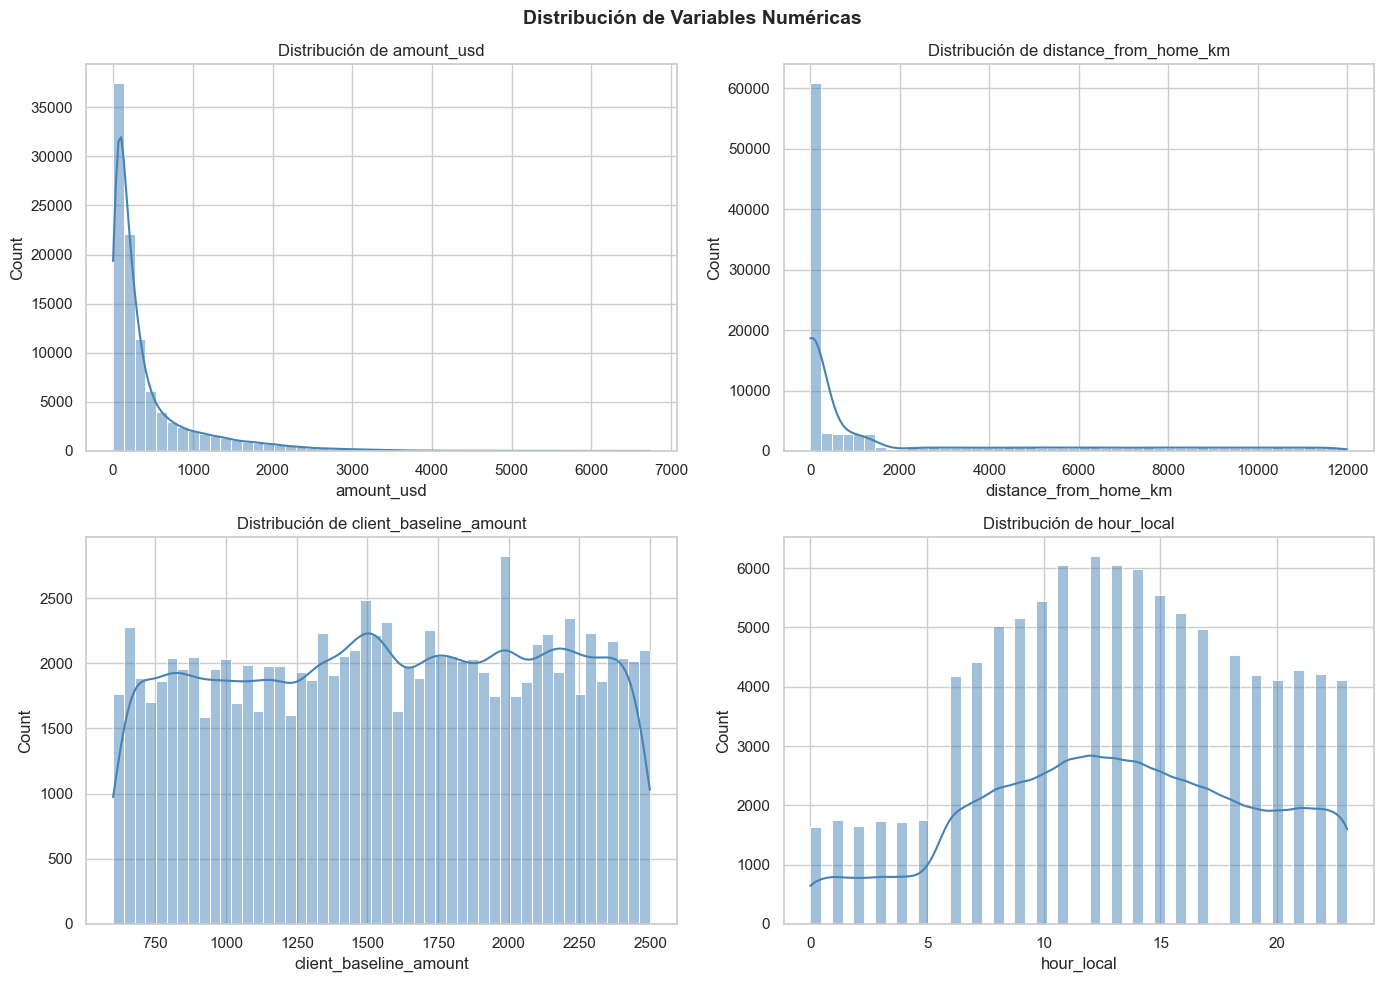

In [67]:
num_cols = ['amount_usd', 'distance_from_home_km', 'client_baseline_amount', 'hour_local']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `amount_usd`: distribución **muy sesgada a la derecha** (media=430, std=598, max=6,731). La mayoría de transacciones son montos pequeños (mediana=200 USD); los outliers de alto valor pueden ser indicadores de fraude.
- `distance_from_home_km`: distribución **bimodal** — la mediana es solo 21 km (la mayoría de transacciones ocurren cerca del hogar), pero la media sube a 1,779 km por el grupo de transacciones muy lejanas (Q3=1,365 km). Esta dispersión extrema es una señal de riesgo importante.
- `client_baseline_amount`: distribución aproximadamente **uniforme** entre 600 y 2,500 USD (media=1,567, std=546), sin sesgo marcado. Refleja el comportamiento típico de gasto del cliente.
- `hour_local`: distribución **unimodal con claro patrón horario** — actividad mínima de 0-5am (~1,650-1,760 tx/hora), sube bruscamente a las 6am (4,189), alcanza el pico entre 11h-13h (~6,000-6,200 tx/hora), y desciende gradualmente por la tarde/noche.

## 11. Boxplots — Detección de Valores Extremos

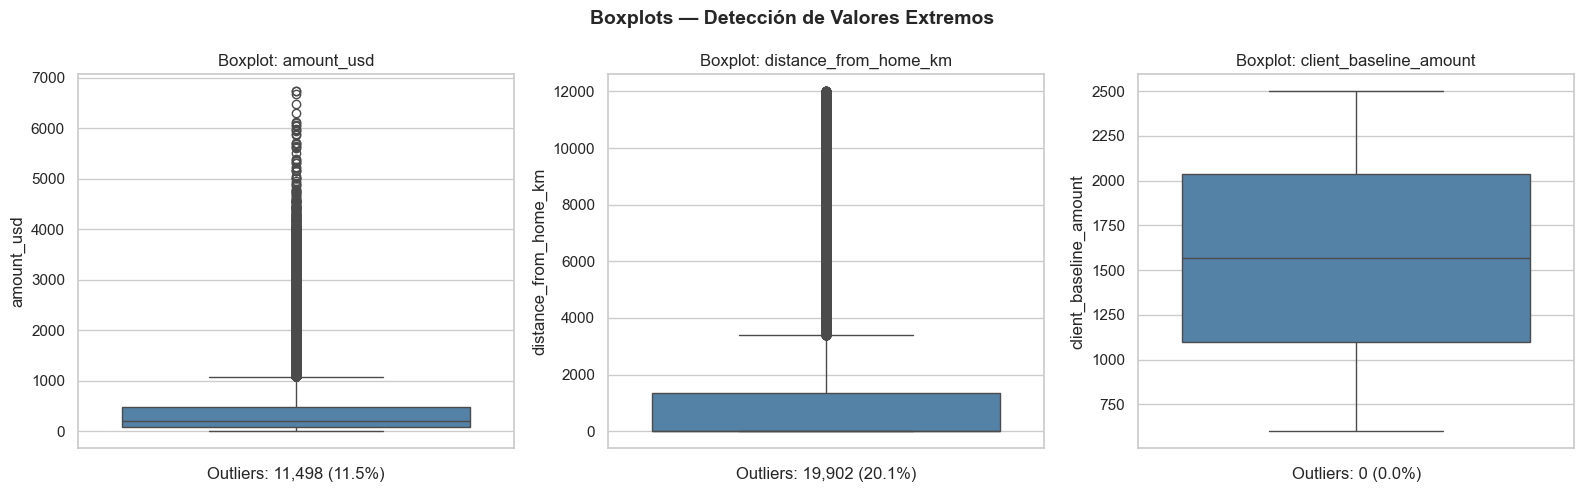

In [68]:
num_box_cols = ['amount_usd', 'distance_from_home_km', 'client_baseline_amount']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_box_cols):
    data = df[col].dropna()
    sns.boxplot(y=data, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers:,} ({outliers/len(data)*100:.1f}%)')

plt.suptitle('Boxplots — Detección de Valores Extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `amount_usd` y `distance_from_home_km` presentan gran cantidad de outliers por encima del bigote superior (IQR × 1.5), lo que confirma el sesgo positivo de los histogramas.
- **Importante:** en detección de fraude, los outliers no deben eliminarse automáticamente — los valores extremos son con frecuencia los casos más sospechosos y contienen información discriminante valiosa.
- `client_baseline_amount` no muestra outliers extremos, lo que confirma su distribución más uniforme.

## 12. Distribución Temporal de Transacciones

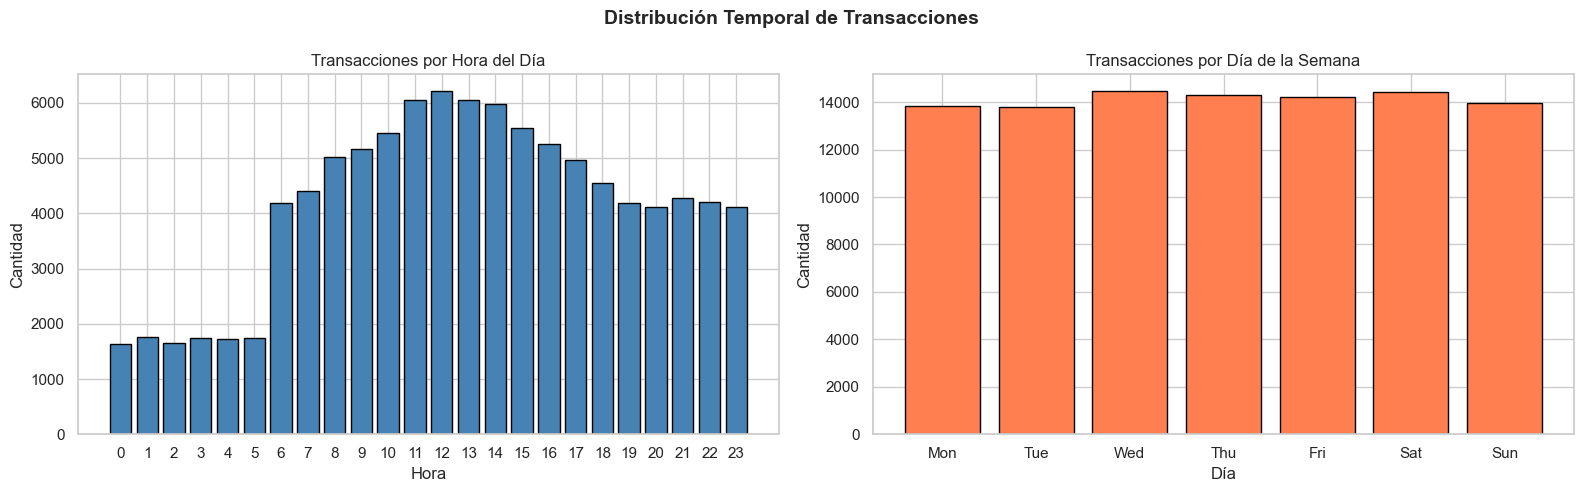

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_counts = df['hour_local'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Transacciones por Hora del Día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticks(range(0, 24))

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(day_counts.index, day_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Transacciones por Día de la Semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Cantidad')

plt.suptitle('Distribución Temporal de Transacciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Por hora:** la actividad es muy baja de madrugada (0-5am: ~1,650-1,760 tx/h), se dispara a las 6am (4,189), alcanza el pico entre 11h-13h (~6,050-6,210 tx/h) y disminuye paulatinamente hacia la noche. Patrón típico de horario bancario y de compras.
- **Por día de semana:** distribución prácticamente uniforme — miércoles y sábado lideran levemente (14,450 c/u), mientras lunes y martes son los días de menor actividad (~13,800). La diferencia entre el día más alto y el más bajo es menor al 5%, indicando que el sistema opera de forma constante toda la semana sin estacionalidad marcada.

## 13. Distribución por Variables Categóricas

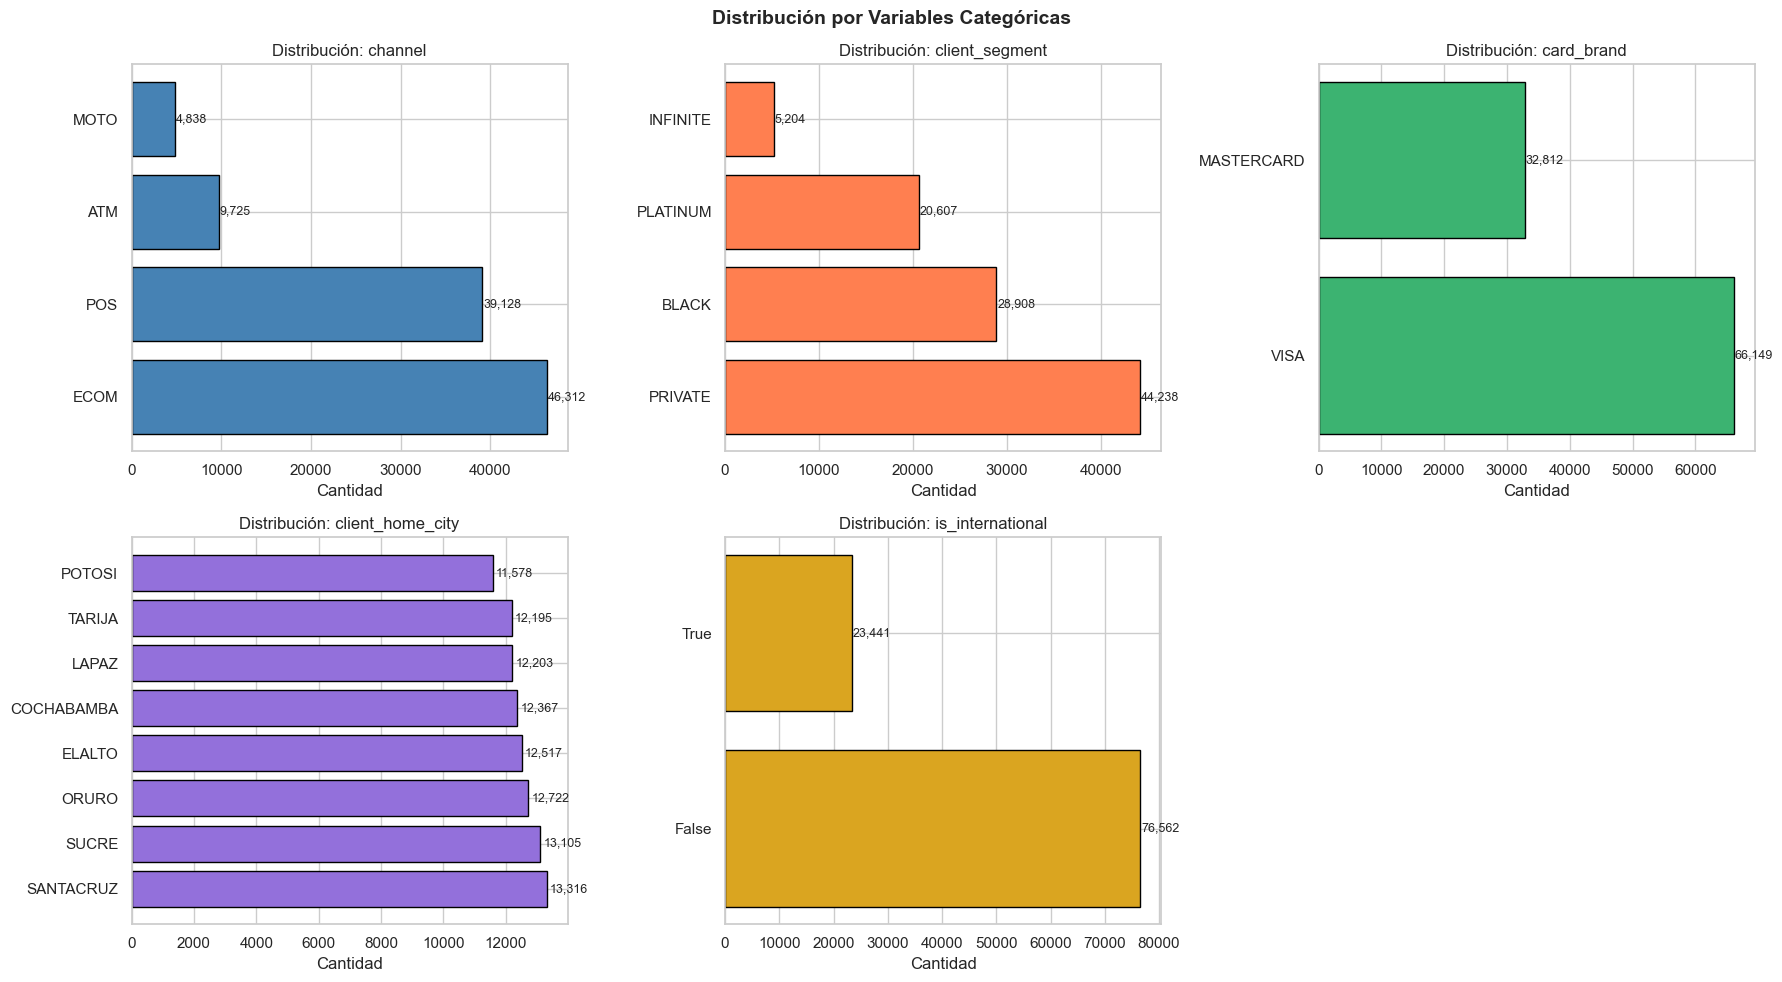

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_data = {
    'channel': df['channel'].value_counts(),
    'client_segment': df['client_segment'].value_counts(),
    'card_brand': df['card_brand'].value_counts(),
    'client_home_city': df['client_home_city'].value_counts(),
    'is_international': df['is_international'].value_counts(),
}
colors_cat = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for i, (col, counts) in enumerate(cat_data.items()):
    axes[i].barh(counts.index.astype(str), counts.values, color=colors_cat[i], edgecolor='black')
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel('Cantidad')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 100, j, f'{v:,}', va='center', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribución por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `channel`: ECOM domina con ~46% de transacciones, seguido de POS y ATM.
- `client_segment`: PRIVATE es el segmento más frecuente (~44%), seguido de PLATINUM.
- `card_brand`: VISA predomina sobre MASTERCARD (~66% vs ~33%).
- `client_home_city`: SANTACRUZ es la ciudad con más clientes, seguida de LAPAZ y SUCRE.
- `is_international`: ~76% de transacciones son nacionales, ~24% internacionales.

## 14. Balance de Clases: Fraude vs No Fraude

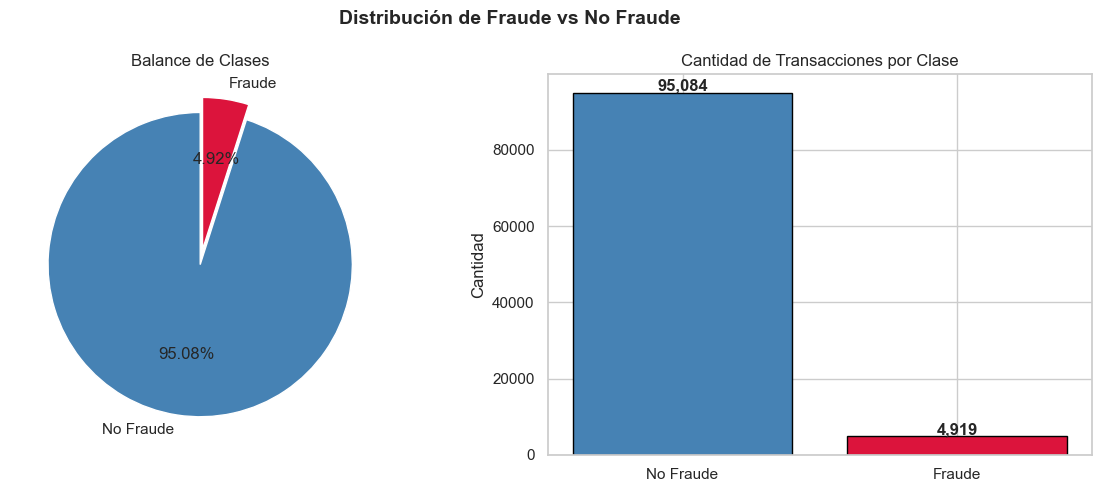

No Fraude: 95,084 (95.08%)
Fraude:    4,919  (4.92%)


In [71]:
fraud_counts = df['is_fraud'].value_counts()
labels = ['No Fraude', 'Fraude']
values = [fraud_counts[False], fraud_counts[True]]
colors_pie = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(values, labels=labels, autopct='%1.2f%%', colors=colors_pie,
            startangle=90, explode=(0, 0.1))
axes[0].set_title('Balance de Clases')

axes[1].bar(labels, values, color=colors_pie, edgecolor='black')
axes[1].set_title('Cantidad de Transacciones por Clase')
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Distribución de Fraude vs No Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"No Fraude: {fraud_counts[False]:,} ({fraud_counts[False]/len(df)*100:.2f}%)")
print(f"Fraude:    {fraud_counts[True]:,}  ({fraud_counts[True]/len(df)*100:.2f}%)")

**Observaciones:**
- El dataset presenta un **desbalance severo de clases**: solo ~4.9% son fraudes (≈4,919 casos de 100,003).
- Para modelos de clasificación esto requiere técnicas como **SMOTE**, undersampling, o `class_weight='balanced'`.
- Las métricas de evaluación deben priorizar **Recall, F1-score y AUC-ROC** sobre Accuracy — un modelo que siempre prediga "No Fraude" tendría 95.1% de accuracy sin detectar ningún fraude real.

## 15. Distribución de Montos: Fraude vs No Fraude

C:\CUDA_TEMP\ipykernel_17884\598633483.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Clase', y='amount_usd',


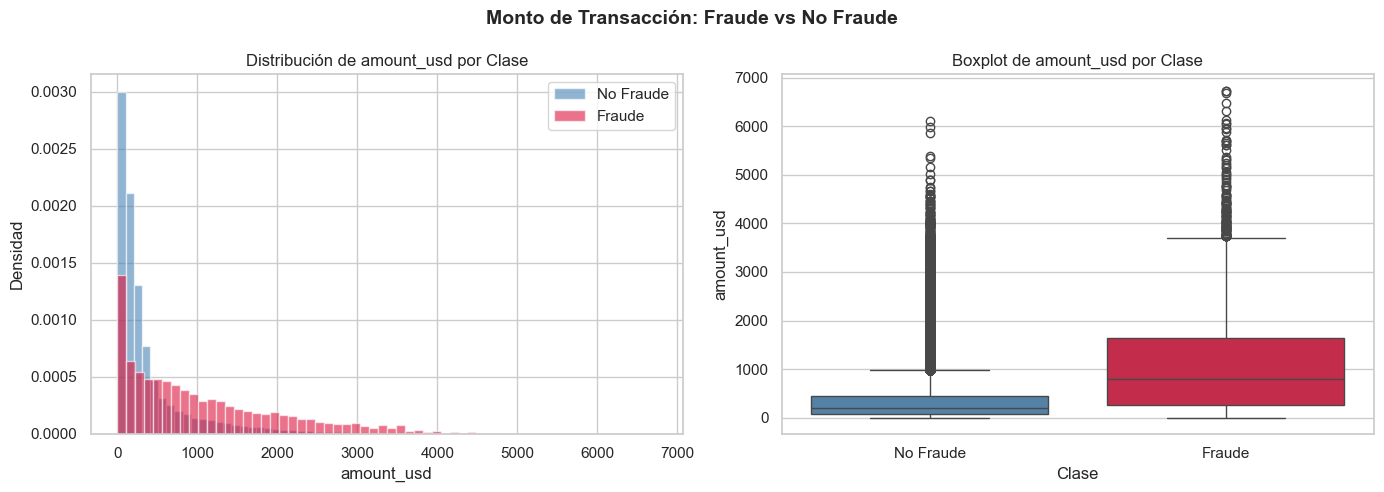

            count     mean      std   min     25%     50%      75%      max
is_fraud                                                                   
False     95084.0   395.91   541.17  0.29   82.23  191.98   440.63  6109.47
True       4919.0  1101.32  1064.67  0.07  267.63  788.66  1648.89  6731.90


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(False, 'steelblue'), (True, 'crimson')]:
    data = df[df['is_fraud'] == label]['amount_usd'].dropna()
    axes[0].hist(data, bins=60, alpha=0.6, color=color,
                 label='No Fraude' if not label else 'Fraude', density=True)
axes[0].set_title('Distribución de amount_usd por Clase')
axes[0].set_xlabel('amount_usd')
axes[0].set_ylabel('Densidad')
axes[0].legend()

df_plot = df[['amount_usd', 'is_fraud']].copy()
df_plot['Clase'] = df_plot['is_fraud'].map({True: 'Fraude', False: 'No Fraude'})
sns.boxplot(data=df_plot, x='Clase', y='amount_usd',
            palette={'Fraude': 'crimson', 'No Fraude': 'steelblue'}, ax=axes[1])
axes[1].set_title('Boxplot de amount_usd por Clase')
axes[1].set_ylabel('amount_usd')

plt.suptitle('Monto de Transacción: Fraude vs No Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('is_fraud')['amount_usd'].describe().round(2))

**Observaciones:**
- Las transacciones fraudulentas tienen un **monto significativamente mayor**: media $1,101 (fraude) vs $396 (legítima) — casi **3× más alto**.
- La mediana confirma la diferencia: $789 (fraude) vs $192 (legítima) — el monto es un **fuerte discriminante**.
- El fraude también tiene mayor dispersión (std=1,065 vs 541), con transacciones que van desde $0.07 hasta $6,732.
- `amount_usd` es una de las variables más predictivas para detección de fraude en este dataset.

## 16. Distancia desde Hogar y Hora por Fraude

C:\CUDA_TEMP\ipykernel_17884\416060133.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Clase', y='distance_from_home_km',


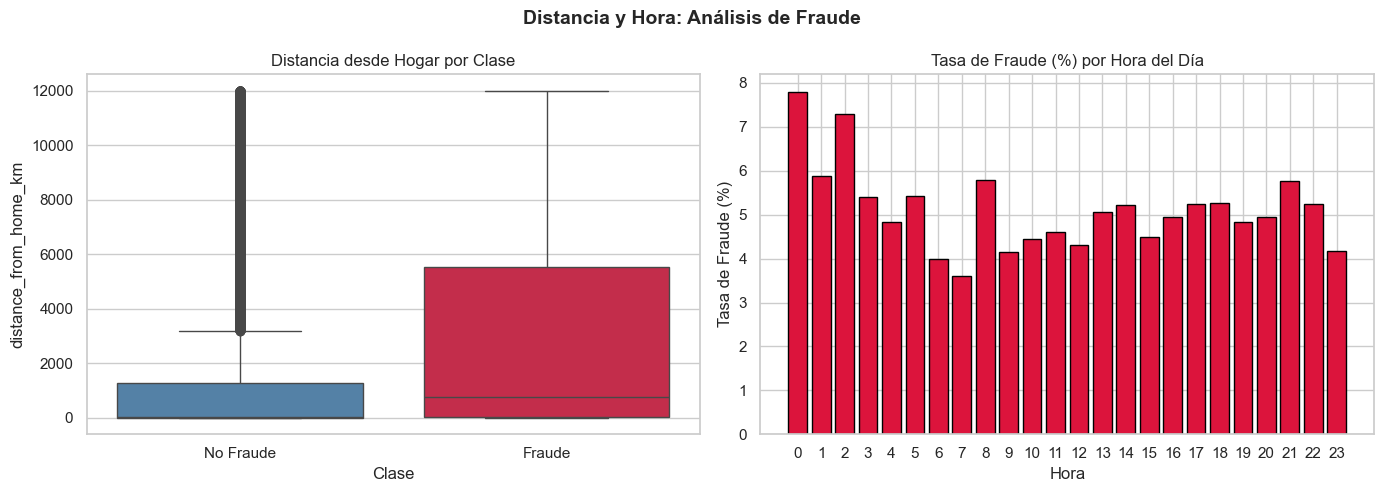

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df[['distance_from_home_km', 'is_fraud']].copy()
df_plot['Clase'] = df_plot['is_fraud'].map({True: 'Fraude', False: 'No Fraude'})
sns.boxplot(data=df_plot, x='Clase', y='distance_from_home_km',
            palette={'Fraude': 'crimson', 'No Fraude': 'steelblue'}, ax=axes[0])
axes[0].set_title('Distancia desde Hogar por Clase')
axes[0].set_ylabel('distance_from_home_km')

fraud_by_hour = df.groupby('hour_local')['is_fraud'].mean() * 100
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='crimson', edgecolor='black')
axes[1].set_title('Tasa de Fraude (%) por Hora del Día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Tasa de Fraude (%)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Distancia y Hora: Análisis de Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Distancia:** la mediana de `distance_from_home_km` en fraudes es **782 km** vs solo **21 km** en legítimas — diferencia de **37×**. El Q3 de fraudes alcanza 5,535 km vs 1,288 km para legítimas. `distance_from_home_km` es el predictor más fuerte del dataset.
- **Tasa de fraude por hora:** los fraudes son más frecuentes en **madrugada** — hora 0 lidera con **7.8%** de tasa, seguida de hora 2 (7.3%) y hora 1 (5.9%). El horario de menor fraude es 7am (3.6%) y 6am (4.0%), coincidiendo con las horas de menor actividad absoluta. El patrón sugiere que los defraudadores actúan cuando el cliente duerme y no puede alertar al banco.

## 17. Variables Categóricas por Fraude

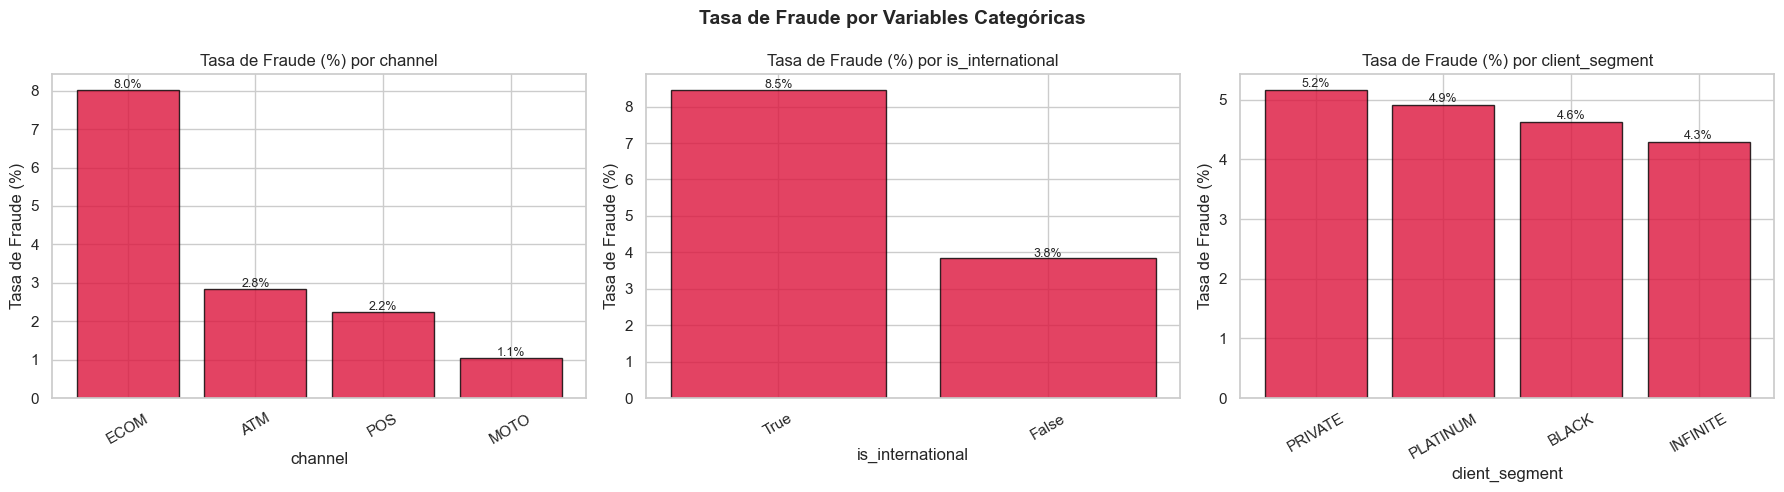

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_fraud_cols = ['channel', 'is_international', 'client_segment']
for i, col in enumerate(cat_fraud_cols):
    fraud_rate = df.groupby(col)['is_fraud'].mean() * 100
    fraud_rate = fraud_rate.sort_values(ascending=False)
    axes[i].bar(fraud_rate.index.astype(str), fraud_rate.values,
                color='crimson', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Tasa de Fraude (%) por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tasa de Fraude (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(fraud_rate.values):
        axes[i].text(j, v + 0.05, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Tasa de Fraude por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Canal:** ECOM tiene la tasa de fraude más alta con **8.0%**, muy por encima de ATM (2.8%), POS (2.2%) y MOTO (1.1%). Las compras en línea son el principal vector de fraude, posiblemente por ausencia de autenticación física (chip/PIN).
- **Internacional:** transacciones internacionales tienen **8.5%** de tasa de fraude vs 3.8% nacionales — más del doble. Combinado con `distance_from_home_km`, confirma que la geolocalización es clave para detectar fraude.
- **Segmento:** las diferencias entre segmentos son pequeñas (PRIVATE 5.2%, PLATINUM 4.9%, BLACK 4.6%, INFINITE 4.3%). El segmento no es un discriminante fuerte por sí solo, aunque PRIVATE lidera levemente.

---
# Fase 3: Balanceo de clases y análisis de fraude

## 1-3. Conteo, Porcentaje y Visualización del Desbalance

=== Conteo de clases ===
No Fraude (False):  95,084
Fraude    (True) :   4,919

=== Porcentaje ===
No Fraude: 95.08%
Fraude:    4.92%


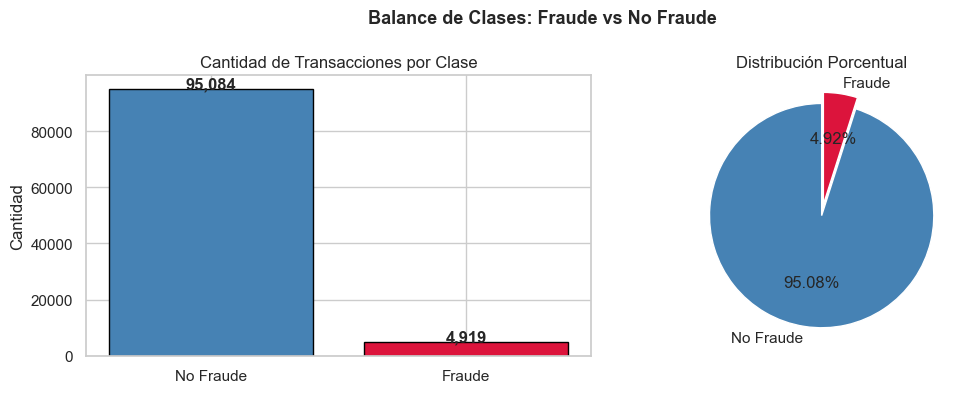

In [75]:
# Conteo de clases (ítem 1)
fraud_counts = df['is_fraud'].value_counts()
print("=== Conteo de clases ===")
print(f"No Fraude (False): {fraud_counts[False]:>7,}")
print(f"Fraude    (True) : {fraud_counts[True]:>7,}")

# Porcentaje de cada clase (ítem 2)
total = len(df)
pct_fraud = fraud_counts[True]  / total * 100
pct_legit  = fraud_counts[False] / total * 100
print(f"\n=== Porcentaje ===")
print(f"No Fraude: {pct_legit:.2f}%")
print(f"Fraude:    {pct_fraud:.2f}%")

# Gráfica de barras + pie (ítem 3)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['No Fraude', 'Fraude']
values = [fraud_counts[False], fraud_counts[True]]
colors_cls = ['steelblue', 'crimson']

axes[0].bar(labels, values, color=colors_cls, edgecolor='black')
axes[0].set_title('Cantidad de Transacciones por Clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(values, labels=labels, autopct='%1.2f%%',
            colors=colors_cls, startangle=90, explode=(0, 0.1))
axes[1].set_title('Distribución Porcentual')

plt.suptitle('Balance de Clases: Fraude vs No Fraude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **95,084 transacciones legítimas (95.08%)** y **4,919 fraudulentas (4.92%)** — de cada 20 transacciones, solo 1 es fraude.
- El desbalance es severo: la clase minoritaria (fraude) representa menos del 5% del total.
- El gráfico de barras muestra la escala de la diferencia; el pie chart aclara los porcentajes exactos.

## 4-5. Proporción y Evaluación del Desbalance

In [76]:
# Proporción legítimas:fraudes (ítem 4)
ratio = fraud_counts[False] / fraud_counts[True]
print(f"Proporción legítimas:fraudes = {ratio:.1f}:1")
print(f"Por cada transacción fraudulenta hay {ratio:.1f} legítimas.\n")

# Evaluación del nivel de desbalance (ítem 5)
print("=== Evaluación del desbalance ===")
if pct_fraud < 1:
    nivel = "EXTREMO (< 1%)"
elif pct_fraud < 5:
    nivel = "ALTO (1% – 5%)"
elif pct_fraud < 20:
    nivel = "MODERADO (5% – 20%)"
else:
    nivel = "LEVE (> 20%)"
print(f"Tasa de fraude: {pct_fraud:.2f}%  →  Desbalance {nivel}")
print(f"\nConclusión: el dataset está DESBALANCEADO. Se requiere estrategia")
print(f"específica para entrenar modelos de clasificación de fraude.")

Proporción legítimas:fraudes = 19.3:1
Por cada transacción fraudulenta hay 19.3 legítimas.

=== Evaluación del desbalance ===
Tasa de fraude: 4.92%  →  Desbalance ALTO (1% – 5%)

Conclusión: el dataset está DESBALANCEADO. Se requiere estrategia
específica para entrenar modelos de clasificación de fraude.


**Observaciones:**
- Proporción **~19.3:1** (por cada fraude hay ~19 transacciones legítimas) → desbalance clasificado como **ALTO (1%–5%)**.
- Un modelo trivial que prediga siempre "No Fraude" tendría **95.08% de accuracy** sin detectar ningún fraude real — la accuracy NO es la métrica adecuada.
- Para LightGBM se recomienda `scale_pos_weight=19` o `is_unbalance=True` para compensar el desbalance durante el entrenamiento.

## 6. Interpretación para Modelo LightGBM

In [77]:
print(f"""
=== ¿Por qué el desbalance importa para LightGBM? ===

El dataset tiene {pct_fraud:.2f}% de fraudes ({fraud_counts[True]:,} casos)
vs {pct_legit:.2f}% de transacciones legítimas ({fraud_counts[False]:,} casos).

Este desbalance implica:

1. SESGO DEL MODELO: sin corrección, LightGBM aprende a predecir casi
   siempre "No Fraude", obteniendo alta accuracy (~{pct_legit:.0f}%) pero
   detectando muy pocos fraudes reales (bajo Recall).

2. MÉTRICA CORRECTA: usar AUC-ROC, F1-score (clase fraude) y Recall,
   NO Accuracy. Un modelo trivial que prediga siempre "No Fraude" ya
   tendría {pct_legit:.2f}% de accuracy.

3. ESTRATEGIAS RECOMENDADAS para LightGBM:
   - scale_pos_weight = {int(ratio)} (ratio legítimas/fraudes ≈ {ratio:.1f})
   - is_unbalance = True (ajuste automático de pesos)
   - O aplicar SMOTE/undersampling antes del entrenamiento

4. OBJETIVO: maximizar Recall (detectar todos los fraudes posibles)
   sin sacrificar demasiada Precision (minimizar falsas alarmas al banco).
""")


=== ¿Por qué el desbalance importa para LightGBM? ===

El dataset tiene 4.92% de fraudes (4,919 casos)
vs 95.08% de transacciones legítimas (95,084 casos).

Este desbalance implica:

1. SESGO DEL MODELO: sin corrección, LightGBM aprende a predecir casi
   siempre "No Fraude", obteniendo alta accuracy (~95%) pero
   detectando muy pocos fraudes reales (bajo Recall).

2. MÉTRICA CORRECTA: usar AUC-ROC, F1-score (clase fraude) y Recall,
   NO Accuracy. Un modelo trivial que prediga siempre "No Fraude" ya
   tendría 95.08% de accuracy.

3. ESTRATEGIAS RECOMENDADAS para LightGBM:
   - scale_pos_weight = 19 (ratio legítimas/fraudes ≈ 19.3)
   - is_unbalance = True (ajuste automático de pesos)
   - O aplicar SMOTE/undersampling antes del entrenamiento

4. OBJETIVO: maximizar Recall (detectar todos los fraudes posibles)
   sin sacrificar demasiada Precision (minimizar falsas alarmas al banco).



## 7. Análisis Mensual y Set de Test: Junio 2025

=== Distribución mensual ===
mes_nombre  total  fraudes  tasa_fraude_pct
     Enero  17230      852         4.944864
   Febrero  15664      778         4.966803
     Marzo  17133      899         5.247184
     Abril  16610      819         4.930765
      Mayo  17199      843         4.901448
     Junio  16073      727         4.523113


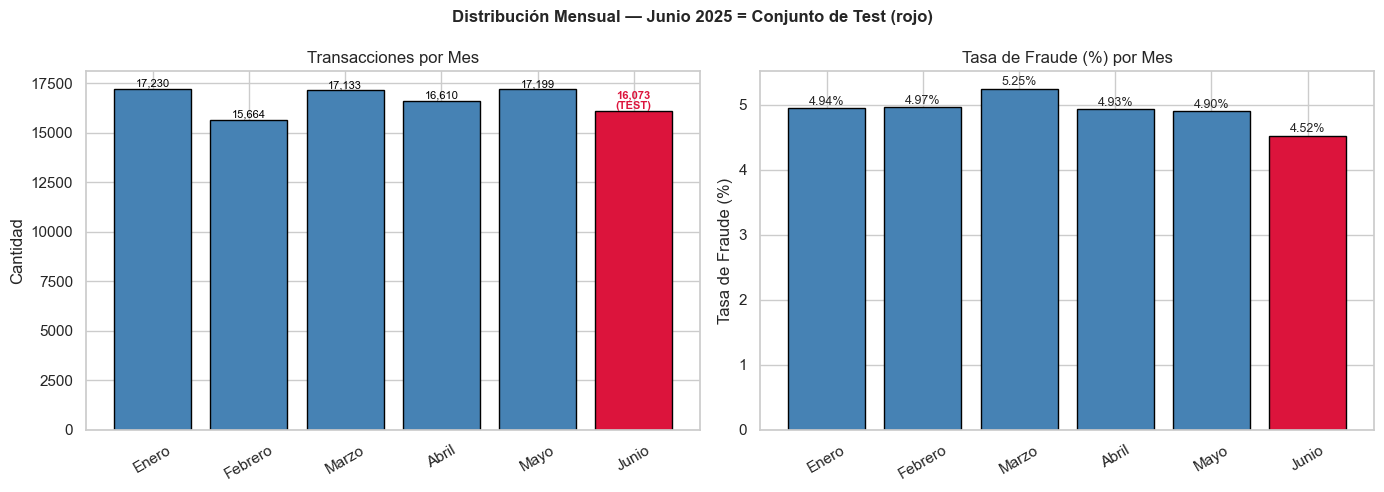


Train (Ene–May): 83,836 filas | Fraudes: 4,191 (5.00%)
Test  (Junio) :  16,073  filas | Fraudes: 727  (4.52%)


In [78]:
# Extraer mes de DE13_local_date (formato MMDD: 101=1ene, 630=30jun)
df_temp = df.copy()
df_temp = df_temp.dropna(subset=['DE13_local_date'])
df_temp['mes'] = (df_temp['DE13_local_date'] // 100).astype(int)
df_temp = df_temp[df_temp['mes'].between(1, 6)]

month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio'}

# Transacciones y tasa de fraude por mes
monthly = df_temp.groupby('mes').agg(
    total=('is_fraud', 'count'),
    fraudes=('is_fraud', 'sum'),
    tasa_fraude=('is_fraud', 'mean')
).reset_index()
monthly['tasa_fraude_pct'] = monthly['tasa_fraude'] * 100
monthly['mes_nombre'] = monthly['mes'].map(month_names)

print("=== Distribución mensual ===")
print(monthly[['mes_nombre', 'total', 'fraudes', 'tasa_fraude_pct']].to_string(index=False))

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['crimson' if m == 6 else 'steelblue' for m in monthly['mes']]

axes[0].bar(monthly['mes_nombre'], monthly['total'], color=bar_colors, edgecolor='black')
axes[0].set_title('Transacciones por Mes')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=30)
for i, (v, m) in enumerate(zip(monthly['total'], monthly['mes'])):
    label = f'{v:,}\n(TEST)' if m == 6 else f'{v:,}'
    axes[0].text(i, v + 100, label, ha='center', fontsize=8,
                 fontweight='bold' if m == 6 else 'normal',
                 color='crimson' if m == 6 else 'black')

axes[1].bar(monthly['mes_nombre'], monthly['tasa_fraude_pct'], color=bar_colors, edgecolor='black')
axes[1].set_title('Tasa de Fraude (%) por Mes')
axes[1].set_ylabel('Tasa de Fraude (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(monthly['tasa_fraude_pct']):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('Distribución Mensual — Junio 2025 = Conjunto de Test (rojo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Separar conjuntos train / test por mes
df_train = df_temp[df_temp['mes'] != 6].copy()
df_test  = df_temp[df_temp['mes'] == 6].copy()
print(f"\nTrain (Ene–May): {len(df_train):,} filas | Fraudes: {df_train['is_fraud'].sum():,} ({df_train['is_fraud'].mean()*100:.2f}%)")
print(f"Test  (Junio) :  {len(df_test):,}  filas | Fraudes: {df_test['is_fraud'].sum():,}  ({df_test['is_fraud'].mean()*100:.2f}%)")

**Observaciones:** *(completar tras ejecutar — ver tabla mensual impresa arriba)*

- Analizar si la tasa de fraude de junio es consistente con el resto de los meses o si hay una desviación significativa.
- Si junio tiene una tasa de fraude muy diferente al promedio de entrenamiento, el modelo podría tener peor rendimiento al evaluar en ese mes.
- Los conjuntos `df_train` y `df_test` quedan listos para la siguiente fase de modelado.

In [79]:
# delete columns which only hold NaN values
print("Columns with only nulls: ", columns_with_only_nulls)
df.drop(columns=columns_with_only_nulls, inplace=True)

Columns with only nulls:  ['DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2']


In [80]:
# fill categorical data 
df = df.assign(
    client_segment=df['client_segment'].fillna('UNKNOWN'),
    card_brand=df['card_brand'].fillna('UNKNOWN'),
    DE44_additional_response_data=df['DE44_additional_response_data'].fillna('UNKNOWN'),
    day_of_week=df['day_of_week'].fillna('Unk'),
    response_description=df['response_description'].fillna('Unknown'),
    DE63_network_specific=df['DE63_network_specific'].fillna('Other')
)

In [81]:
# fill numerical data
df = df.assign(
    DE9_conversion_rate_billing=df['DE9_conversion_rate_billing'].fillna(
        df['DE9_conversion_rate_billing'].median()
    ),
    DE15_settlement_date=df['DE15_settlement_date'].fillna(
        df['DE15_settlement_date'].median()
    ),
    DE23_card_seq_number=df['DE23_card_seq_number'].fillna(
        df['DE23_card_seq_number'].median()
    ),
    DE58_authorizing_agent_id=df['DE58_authorizing_agent_id'].fillna(0),
    DE61_pos_extended_data=df['DE61_pos_extended_data'].fillna(
        df['DE61_pos_extended_data'].median()
    ),
    DE100_receiving_institution_id=df['DE100_receiving_institution_id'].fillna(0),
    distance_from_home_km=df['distance_from_home_km'].fillna(
        df['distance_from_home_km'].median()
    )
)

In [82]:
# Needs some other handling 
df = df.assign(
    DE35_track2_data_masked=df['DE35_track2_data_masked'].fillna(
        df['DE35_track2_data_masked'].mode()[0]
    ),
    DE38_authorization_code=df['DE38_authorization_code'].fillna(
        df['DE38_authorization_code'].mode()[0]
    ),
    DE41_terminal_id=df['DE41_terminal_id'].fillna(
        df['DE41_terminal_id'].mode()[0]
    ),
    DE42_card_acceptor_id=df['DE42_card_acceptor_id'].fillna(
        df['DE42_card_acceptor_id'].mode()[0]
    ),
    DE102_account_id_1=df['DE102_account_id_1'].fillna(
        df['DE102_account_id_1'].mode()[0]
    ),
    DE123_pos_data_code=df['DE123_pos_data_code'].fillna(
        df['DE123_pos_data_code'].mode()[0]
    )
)

---
# Fase 4: Selección de Features — Fraude en Venues de Entretenimiento

**Contexto:** El objetivo es detectar fraude en comercios de entretenimiento (cines, conciertos, bares, restaurantes).
Se priorizan variables de ubicación geográfica, tipo de comercio (MCC), temporales, perfil del comprador y seguridad de la transacción.

### Criterios de eliminación
| Criterio | Descripción |
|----------|-------------|
| **Constante** | Mismo valor en todas las filas — zero variance |
| **Casi constante** | Un único valor válido (~99 %) en todo el dataset |
| **Identificador único** | UUID o número secuencial por transacción — el modelo lo memoriza sin generalizar |
| **Redundante** | La misma información ya existe en una columna más limpia |

> `DE7_transmission_datetime` y `DE12_local_time` se **conservan** porque pueden servir para extraer
> features adicionales de día y hora con mayor granularidad que las columnas derivadas.

In [ ]:
COLUMNS_TO_DROP = [

    # --- CONSTANTES: mismo valor en todas las filas (zero variance) ---
    'bank_code',                       # Siempre 'BO-VIP'
    'bank_name',                       # Siempre 'BO-VIP'
    'bank_country',                    # Siempre 'BO'
    'bank_tier',                       # Siempre 'vip'
    'DE63_network_specific',           # ~99 % 'BO-VIP'; solo ~1 % nulos
    'DE58_authorizing_agent_id',       # Solo 1 valor numérico válido en todo el dataset
    'DE100_receiving_institution_id',  # Solo 1 valor numérico válido en todo el dataset

    # --- IDENTIFICADORES ÚNICOS: un valor distinto por fila, no generalizan ---
    'transaction_id',                  # UUID único por transacción
    'DE11_STAN',                       # System Trace Audit Number: número de traza único
    'DE37_retrieval_reference_number', # RRN: referencia única de conciliación
    'DE38_authorization_code',         # Código de autorización: ~96 700 únicos
    'DE35_track2_data_masked',         # Datos pista 2 enmascarados (variante del PAN)
    'pan_masked',                      # PAN enmascarado: el BIN ya está en card_brand
    'pan_hash',                        # Hash del PAN: identificador de tarjeta
    'DE2_PAN',                         # PAN numérico (campo ISO crudo), redundante

    # --- REDUNDANTES: misma información en otra columna más limpia ---
    'amount_local',                    # Mismo monto que amount_usd en moneda local
    'amount_tx_currency',              # Redundante con amount_usd
    'DE4_amount_transaction',          # Campo ISO crudo del monto; amount_usd es la versión normalizada
    'DE6_amount_cardholder_billing',   # Monto de facturación: misma magnitud que amount_usd
    'DE49_currency_code_transaction',  # Código de moneda; capturado en is_international + DE19
    'DE50_currency_code_settlement',   # Moneda de liquidación: redundante con DE49/is_international
    'DE51_currency_code_billing',      # Moneda de facturación: redundante con DE49/is_international
    'currency_tx_alpha',               # Código alfa de moneda: redundante con is_international
]

cols_existentes = [c for c in COLUMNS_TO_DROP if c in df.columns]
cols_ya_eliminadas = [c for c in COLUMNS_TO_DROP if c not in df.columns]

print(f"Columnas antes:              {df.shape[1]}")
print(f"A eliminar (en df):          {len(cols_existentes)}")
if cols_ya_eliminadas:
    print(f"Ya eliminadas previamente:   {cols_ya_eliminadas}")

df_model = df.drop(columns=cols_existentes)

print(f"Columnas después:            {df_model.shape[1]}")
print(f"Reducción total:             {df.shape[1] - df_model.shape[1]} columnas")

In [ ]:
print("=== Columnas resultantes del df_model ===\n")

grupos = {
    "Perfil del cliente": [
        'client_id', 'client_segment', 'client_home_city', 'client_baseline_amount'
    ],
    "Tipo de comercio / venue": [
        'DE18_merchant_category_code', 'DE43_card_acceptor_name_location',
        'DE42_card_acceptor_id', 'DE41_terminal_id'
    ],
    "Geográficas / internacionalidad": [
        'distance_from_home_km', 'is_international', 'DE19_acquirer_country_code'
    ],
    "Temporales": [
        'hour_local', 'day_of_week', 'DE13_local_date',
        'DE7_transmission_datetime', 'DE12_local_time', 'DE15_settlement_date', 'DE14_expiration_date'
    ],
    "Seguridad del POS / modo de captura": [
        'DE22_pos_entry_mode', 'DE52_pin_data_present', 'DE55_emv_data_present',
        'DE25_pos_condition_code', 'DE60_pos_terminal_type', 'DE61_pos_extended_data',
        'DE123_pos_data_code'
    ],
    "Respuesta del emisor": [
        'DE39_response_code', 'response_description', 'DE44_additional_response_data', 'approved'
    ],
    "Monto y canal": [
        'amount_usd', 'channel', 'card_brand', 'DE9_conversion_rate_billing'
    ],
    "Tipo de operación": [
        'MTI', 'DE3_processing_code', 'DE32_acquiring_institution_id',
        'DE23_card_seq_number', 'DE102_account_id_1'
    ],
    "Target": ['is_fraud'],
}

total = 0
for grupo, cols in grupos.items():
    presentes = [c for c in cols if c in df_model.columns]
    total += len(presentes)
    print(f"  [{len(presentes):2d}] {grupo}")
    for c in presentes:
        print(f"         • {c}")
    print()

print(f"Total columnas en df_model: {df_model.shape[1]}")
print(f"Filas:                      {df_model.shape[0]:,}")

---
# Fase 4: Selección de Features — Fraude en Venues de Entretenimiento

**Contexto:** El objetivo es detectar fraude específicamente en comercios de entretenimiento:
cines, conciertos, bares y restaurantes. Esto implica priorizar variables de:

- **Ubicación geográfica:** distancia del hogar, país del comercio, ciudad
- **Tipo de comercio (MCC):** código de categoría del comercio, nombre/ubicación del establecimiento
- **Temporales:** hora del día, día de semana, fecha (las venues de entretenimiento operan de noche y fines de semana)
- **Perfil del comprador:** monto habitual del cliente, segmento, historial por cliente
- **Seguridad de la transacción:** modo de ingreso de tarjeta (chip/banda/manual), uso de PIN, EMV
- **Comportamiento de la transacción:** canal, respuesta del emisor, internacionalidad

### Criterios de eliminación aplicados
| Criterio | Descripción |
|----------|-------------|
| **Constante** | Mismo valor en todas las filas — no aporta información |
| **Identificador único** | UUID o número secuencial por transacción — no predictivo |
| **Redundante** | Información ya capturada por otra columna más limpia |
| **Casi constante** | Prácticamente un solo valor válido (~99%) |